In [9]:
import pandas as pd
import numpy as np

# ---------------------------
# LOAD FILE
# ---------------------------
data = pd.read_excel("pfr.xlsx", skiprows=240, header=None)
data = data.dropna()

# ---------------------------
# EXTRACT COLUMNS (NO 'z' yet!)
# ---------------------------
z = data.iloc[:, 1]
r = data.iloc[:, 2]
T = data.iloc[:, 11]

# ---------------------------
# CREATE CLEAN DATASET
# ---------------------------
data_clean = pd.DataFrame({
    'z': z,
    'r': r,
    'T': T
})

print(data_clean.head())

          z         r       T
0  0.031568  0.000061  777.83
1  0.028926  0.000038  721.05
2  0.034308   0.00007  775.11
3   0.03422  0.000087  724.65
6   0.03123  0.000055  778.98


Hotspot threshold: 791.1208316513112
          z         r       T  hotspot
0  0.031568  0.000061  777.83        0
1  0.028926  0.000038  721.05        0
2  0.034308   0.00007  775.11        0
3   0.03422  0.000087  724.65        0
6   0.03123  0.000055  778.98        0
Epoch 0, Loss: 0.6540824770927429
Epoch 10, Loss: 0.24025046825408936
Epoch 20, Loss: 0.0319950133562088
Epoch 30, Loss: 0.002287105889990926
Epoch 40, Loss: 0.0004073182353749871
Epoch 50, Loss: 0.00018324459961149842
Epoch 60, Loss: 0.0001223857543664053
Epoch 70, Loss: 0.00010192670742981136
Epoch 80, Loss: 9.546383080305532e-05
Epoch 90, Loss: 8.700394391780719e-05
Accuracy: 100.00%


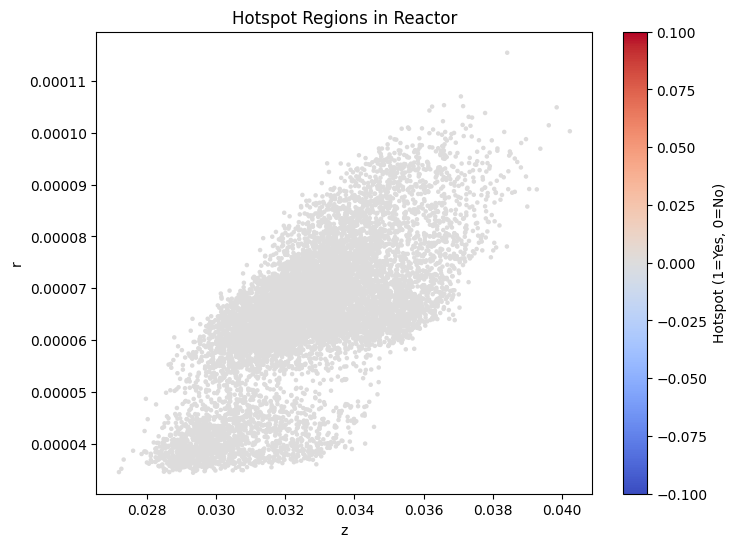

In [10]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# ---------------------------
# 1. LOAD & CLEAN DATA
# ---------------------------
data = pd.read_excel("pfr.xlsx", skiprows=240, header=None)
data = data.dropna()

# Extract correct columns (based on your file)
z = data.iloc[:, 1]
r = data.iloc[:, 2]
T = data.iloc[:, 11]

# Create clean dataframe
df = pd.DataFrame({'z': z, 'r': r, 'T': T})

# ---------------------------
# 2. CREATE HOTSPOT LABELS
# ---------------------------
threshold = df['T'].mean() + 1.5 * df['T'].std()
df['hotspot'] = (df['T'] > threshold).astype(int)

print("Hotspot threshold:", threshold)
print(df.head())

# ---------------------------
# 3. PREPARE DATA
# ---------------------------
X = df[['z', 'r']].values
y = df['hotspot'].values.reshape(-1, 1)

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)
y_train = torch.FloatTensor(y_train)
y_test = torch.FloatTensor(y_test)

# ---------------------------
# 4. MODEL
# ---------------------------
class HotspotNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

model = HotspotNN()

# ---------------------------
# 5. TRAINING
# ---------------------------
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

for epoch in range(100):
    model.train()

    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)

    loss.backward()
    optimizer.step()

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item()}")

# ---------------------------
# 6. EVALUATION
# ---------------------------
model.eval()
with torch.no_grad():
    preds = model(X_test)
    preds = (preds > 0.5).float()

accuracy = (preds == y_test).float().mean()
print(f"Accuracy: {accuracy.item()*100:.2f}%")

# ---------------------------
# 7. VISUALIZATION
# ---------------------------
plt.figure(figsize=(8,6))
plt.scatter(df['z'], df['r'], c=df['hotspot'], cmap='coolwarm', s=5)
plt.colorbar(label='Hotspot (1=Yes, 0=No)')
plt.xlabel('z')
plt.ylabel('r')
plt.title('Hotspot Regions in Reactor')
plt.show()